In [6]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import glob
import gc
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

# Helper Functions

In [7]:
def open_dataset(path, date_column):
    csv_files = sorted(glob.glob(path))
    dfs = []
    for f in csv_files:
        temp_df = pd.read_csv(f, parse_dates=[date_column])
        dfs.append(temp_df)
    df = pd.concat(dfs, ignore_index=True)
    del dfs
    gc.collect()
    return df

# Load & Preprocess Data

In [8]:
TARGET_COL = "Carbon intensity gCO₂eq/kWh (direct)"

df = open_dataset("../emissions-data/*.csv", "Datetime (UTC)")
df["Datetime (UTC)"] = pd.to_datetime(df["Datetime (UTC)"])
df = df.sort_values("Datetime (UTC)").set_index("Datetime (UTC)")

# Features
df["hour"] = df.index.hour
df["dow"] = df.index.dayofweek
df["month"] = df.index.month
df["day_of_year"] = df.index.dayofyear

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

df["diff_1"] = df[TARGET_COL].diff(1)
df["diff_24"] = df[TARGET_COL].diff(24)

df = df.drop(columns=["Data estimated", "Country", "Zone name", "Data source", "Data estimation method"])
df = df.dropna()

# Get test data
y_test = df.loc["2025", TARGET_COL].astype(np.float32)
print(f"Test data shape: {y_test.shape}")
print(f"Date range: {df.loc['2025'].index.min()} to {df.loc['2025'].index.max()}")

Test data shape: (8760,)
Date range: 2025-01-01 00:00:00 to 2025-12-31 23:00:00


# Load Models

## Load SARIMA Model

In [9]:
print("\n" + "="*60)
print("Loading SARIMA model...")
print("="*60)
path = "export_sarima/"
sarima_result = joblib.load(path + "sarima_model.joblib")
sarima_feature_scaler = joblib.load(path + "sarima_feature_scaler.joblib")
sarima_target_scaler = joblib.load(path + "sarima_target_scaler.joblib")

# Prepare exogenous features for SARIMA
EXOG_FEATURES = ["hour", "dow", "month", "hour_sin", "hour_cos", "year_sin", "year_cos", "diff_1", "diff_24"]
x_test = df.loc["2025"][EXOG_FEATURES].astype(np.float32)
x_test = pd.DataFrame(
    sarima_feature_scaler.transform(x_test),
    columns=EXOG_FEATURES
)

x_test_reset = x_test.reset_index(drop=True)
sarima_forecast = sarima_result.get_forecast(steps=len(y_test), exog=x_test_reset).predicted_mean

print(f"SARIMA forecast shape: {sarima_forecast.shape}")


Loading SARIMA model...
SARIMA forecast shape: (8760,)


## Load LSTM Models

In [10]:
print("\nLoading LSTM models...")
LSTM_MODELS = {
    "LSTM_v1": "carbon_model_lstm.tflite",
    # "LSTM_v2": "carbon_model_lstm_v2.tflite",
    # "LSTM_v3": "carbon_model_lstm_v3.tflite",
    "LSTM_v4": "carbon_model_lstm_v4.tflite",
}

lstm_forecasts = {}
for name, path in LSTM_MODELS.items():
    if os.path.exists(path):
        interpreter = tf.lite.Interpreter(model_path=path)
        interpreter.allocate_tensors()
        lstm_forecasts[name] = interpreter
        print(f"  Loaded {name}")
    else:
        print(f"  {path} not found")


Loading LSTM models...
  Loaded LSTM_v1
  Loaded LSTM_v4


# Compare Models

In [11]:
print("\n" + "="*60)
print("MODEL COMPARISON ON 2025 TEST DATA")
print("="*60)

# SARIMA metrics
sarima_mae = mean_absolute_error(y_test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(y_test, sarima_forecast))
sarima_r2 = r2_score(y_test, sarima_forecast)
sarima_mape = np.mean(np.abs((y_test - sarima_forecast) / y_test)) * 100

print(f"\n{'Model':<15} {'MAE':<12} {'RMSE':<12} {'R²':<10} {'MAPE':<10}")
print("-" * 60)
print(f"{'SARIMA':<15} {sarima_mae:<12.4f} {sarima_rmse:<12.4f} {sarima_r2:<10.4f} {sarima_mape:<10.2f}%")

# Load diagnostics from other models if available
for model_name in ["LSTM_v1", "LSTM_v2", "LSTM_v3", "LSTM_v4"]:
    diag_file = f"training_log_{model_name.lower()}.csv" if os.path.exists(f"training_log_{model_name.lower()}.csv") else None
    if diag_file and os.path.exists(diag_file):
        try:
            log_df = pd.read_csv(diag_file)
            # Print last row (best metrics)
            if not log_df.empty:
                last_row = log_df.iloc[-1]
                print(f"{model_name:<15} {last_row.get('val_mae', np.nan):<12.4f} {last_row.get('val_rmse', np.nan):<12.4f} {last_row.get('val_r2', np.nan):<10.4f}")
        except:
            pass


MODEL COMPARISON ON 2025 TEST DATA

Model           MAE          RMSE         R²         MAPE      
------------------------------------------------------------
SARIMA          72.9145      79.3195      -3.4636    nan       %
LSTM_v2         0.4290       nan          nan       
LSTM_v3         0.4693       nan          nan       
LSTM_v4         0.4427       nan          nan       


# Seasonal Performance Analysis

In [12]:
print("\n" + "="*60)
print("SEASONAL PERFORMANCE ANALYSIS")
print("="*60)

test_dates = df.loc["2025"].index
summer_mask = test_dates.month.isin([6, 7, 8])
winter_mask = test_dates.month.isin([12, 1, 2])

sarima_summer_mae = mean_absolute_error(y_test[summer_mask], sarima_forecast[summer_mask])
sarima_winter_mae = mean_absolute_error(y_test[winter_mask], sarima_forecast[winter_mask])

print(f"\nSARIMA:")
print(f"  Summer MAE: {sarima_summer_mae:.4f} gCO₂eq/kWh")
print(f"  Winter MAE: {sarima_winter_mae:.4f} gCO₂eq/kWh")


SEASONAL PERFORMANCE ANALYSIS

SARIMA:
  Summer MAE: 82.9443 gCO₂eq/kWh
  Winter MAE: 60.2646 gCO₂eq/kWh


# Visualisation

## Plot 1: Full year forecast comparison

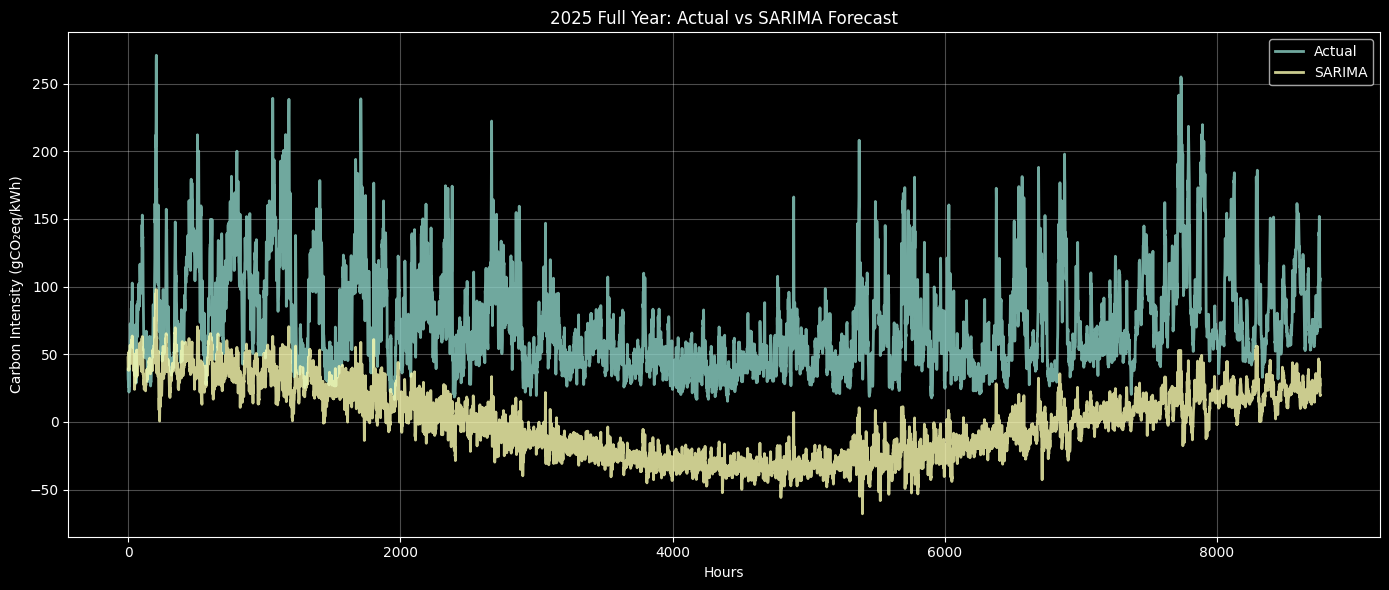

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(range(len(y_test)), y_test.values, label="Actual", linewidth=2, alpha=0.8)
ax.plot(range(len(sarima_forecast)), sarima_forecast.values, label="SARIMA", linewidth=2, alpha=0.8)
ax.set_title("2025 Full Year: Actual vs SARIMA Forecast")
ax.set_xlabel("Hours")
ax.set_ylabel("Carbon Intensity (gCO₂eq/kWh)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 2: Error distribution

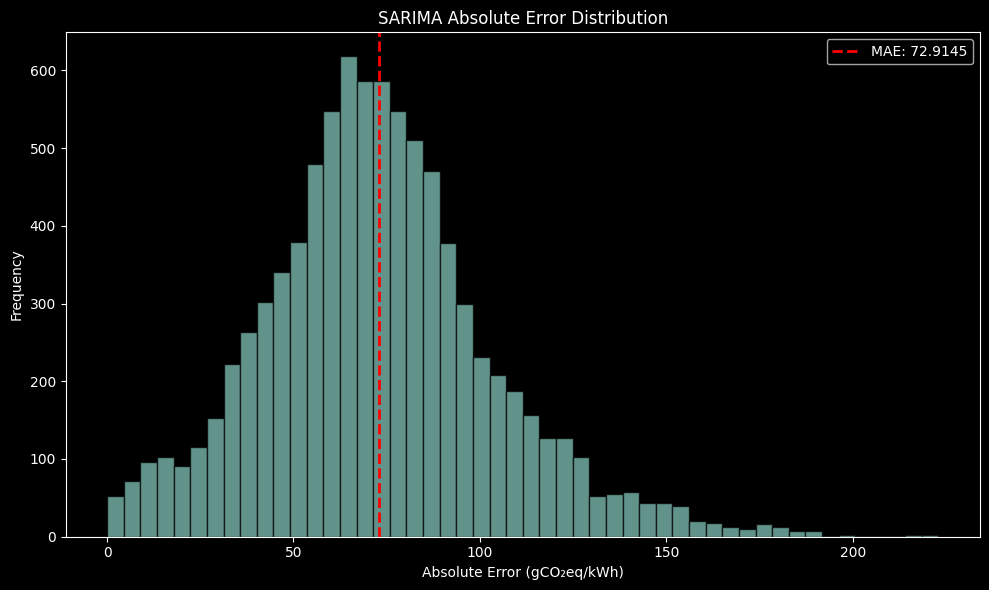

In [14]:
sarima_errors = np.abs(y_test.values - sarima_forecast.values)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(sarima_errors, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(sarima_mae, color='red', linestyle='--', linewidth=2, label=f'MAE: {sarima_mae:.4f}')
ax.set_title("SARIMA Absolute Error Distribution")
ax.set_xlabel("Absolute Error (gCO₂eq/kWh)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

## Save Comparision Results

In [15]:
comparison_results = {
    "sarima": {
        "mae": float(sarima_mae),
        "rmse": float(sarima_rmse),
        "r2": float(sarima_r2),
        "mape": float(sarima_mape),
        "summer_mae": float(sarima_summer_mae),
        "winter_mae": float(sarima_winter_mae)
    }
}

with open("model_comparison_results.json", "w") as f:
    json.dump(comparison_results, f, indent=4)

print("\nComparison results saved to model_comparison_results.json")


Comparison results saved to model_comparison_results.json
